In [8]:
import h5py
import numpy as np
import glob
import matplotlib.pyplot as plt

from pade.pade import pade
from helper_functions import E_to_speed

# Constants
q_e = 1.60217646e-19
h_bar = 1.054571817e-34

In [9]:
# --- Extract beam-aligned field ---

def extract_beam_Ez(filename):
    """
    Extract the beam-aligned electric field component (Ez) from the HDF5 file.
    """

    with h5py.File(filename, 'r') as f:
        Ez = f['ez'][:]   

    return Ez

In [10]:
# --- Compute pade DFT ---

def padeDFT(t, Efield, N, max_energy):
    """Compute the pade DFT for each time series of electric field values in Efield

    Args:
        t (itertor): array of times
        Efield (np.array): 2D array with pixels on the first axis and Efield data on the second axis
        N (int): Number of frequencies you want to evaluate the DFT at
        max_energy (float): Max energy of the EELS spectrum in eV

    Returns:
        np.array: 2D array of pixels * N padeDFT values for the N frequencies
        np.array: array of N frequencies at which the padeDFT has been evaluated
    """

    w_max = max_energy * q_e / h_bar
    freqs = np.linspace(0, w_max, N)

    E_hat = np.zeros((Efield.shape[0], len(freqs)), dtype='complex128')

    for i, x_t in enumerate(Efield.T):
        E_hat[i], freqs = pade(t, x_t, read_freq=freqs, baseline='none')

    return E_hat, freqs 

In [11]:
# --- Compute loss probability ---

def compute_Gamma(freqs, E_hat, dz, velocity):

    """Integrates over the pixels for each frequency and multiply by prefactor

    Args:
        freqs (np.array): frequencies corresponding to the Fourier transforms of the field E_hat
        E_hat (np.array): 2D array with frequency components on first axis and spatial components on second axis
        resolution (_type_): meters per pixel
        velocity (_type_): velocity of electron

    Returns:
        np.array: 1D array of loss probabilities per frequency
    """
    
    Gamma = np.zeros(len(freqs)) 
    
    for i_omega in range(1, len(freqs)):
        omega = freqs[i_omega]

        for iz, Ez_omega in enumerate(E_hat.T[i_omega]): 

            z = iz * dz

            phase = np.exp(1j * omega * z / velocity)

            Gamma[i_omega] += (Ez_omega * phase).real * dz

        Gamma[i_omega] *= q_e / (np.pi * h_bar * omega)
        
    return Gamma

In [12]:
# --- Gaussian broadening ---
def gaussian(x, mu, sigma):
    return 1 / np.sqrt(2 * np.pi * sigma**2) * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [16]:
# --- Processing pipeline ---

def main():

    files = sorted(glob.glob("EELS_3D-out/EELS_3D-*.h5"))

    empty_files = [f for f in files if "EMPTY" in f]
    crystal_files = [f for f in files if "CRYSTAL" in f]

    print(f"Found {len(empty_files)} empty files")
    print(f"Found {len(crystal_files)} crystal files")

    if len(empty_files) != 1:
        raise ValueError("Expected exactly one EMPTY file")

    empty_file = empty_files[0]
    Ez_empty = extract_beam_Ez(empty_file)

    print("\nREFERENCE (EMPTY)")
    print("File:", empty_file)
    print("Shape:", Ez_empty.shape)
    print("dtype:", Ez_empty.dtype)

    EELS_spectra = []

    # --- Process all crystals ---
    for filename in crystal_files:
    
        Ez = extract_beam_Ez(filename)

        print("\n--- DEBUG ---")
        print("File:", filename)
        print("Shape:", Ez.shape)
        print("dtype:", Ez.dtype)
        print("min/max:", np.min(Ez), np.max(Ez))

        if Ez.shape != Ez_empty.shape:
            raise ValueError(
                f"Mismatch between:\n{filename}\nand EMPTY reference"
            )

        induced = Ez - Ez_empty

        # time axis
        N = induced.shape[0]
        L = induced.shape[1]

        t = np.linspace(0, 1, N)
        dz = 1 / L

        velocity = E_to_speed(1e5) * 29979245
        print("induced stats:", np.min(induced), np.max(induced), np.mean(induced))
        print("induced norm:", np.linalg.norm(induced))
        # Padé DFT
        M = N
        FT, freqs = padeDFT(t, induced, M, max_energy=2.1)

        # EELS
        Gamma = compute_Gamma(freqs, FT.T, dz, velocity)

        EELS_spectra.append((freqs, Gamma))

    # --- Energy + convolution ---
    sigma = 30e-3 / (2 * np.sqrt(2 * np.log(2)))  # FWHM → sigma

    for i, (freqs, Gamma) in enumerate(EELS_spectra):
        
        #extended spectrum
        freqs_ext = np.append(-freqs[0:-1], freqs)
        Gamma_ext = np.append(np.zeros(len(freqs) - 1), Gamma)

        gauss = gaussian(freqs_ext * h_bar / q_e, 0, sigma)

        Gamma_conv = np.convolve(Gamma_ext, gauss, mode='same')

        # Plotting
        plt.figure()
        plt.title(f"EELS Spectrum {i}")

        plt.plot(freqs_ext * h_bar / q_e, Gamma_conv)

        plt.xlabel("Energy Loss (eV)")
        plt.ylabel("Intensity (arb.)")
        plt.xlim(-0.25, 2)
        
        plt.hlines(0, -0.25, 2, colors='gray', linestyles='--')

    plt.show()

if __name__ == "__main__":
    main()



Found 1 empty files
Found 1 crystal files

REFERENCE (EMPTY)
File: EELS_3D-out/EELS_3D-EMPTY_a9_r245_x9_W1.2_cavity0.h5
Shape: (365, 406, 161, 5)
dtype: float64

--- DEBUG ---
File: EELS_3D-out/EELS_3D-CRYSTAL_Efield_a9_r245_no_cavity.h5
Shape: (161, 2)
dtype: float64
min/max: 0.0 0.0


ValueError: Mismatch between:
EELS_3D-out/EELS_3D-CRYSTAL_Efield_a9_r245_no_cavity.h5
and EMPTY reference

In [46]:

import h5py

filename = "EELS_3D-out/EELS_3D-CRYSTAL_Efield_a9_r245_no_cavity.h5"

with h5py.File(filename, "r") as f:
    def print_tree(name, obj):
        print(name)
        if isinstance(obj, h5py.Dataset):
            print("   shape:", obj.shape)
            print("   dtype:", obj.dtype)

    f.visititems(print_tree)


ez
   shape: (161, 2)
   dtype: float64


In [47]:
with h5py.File(filename, "r") as f:
    dset = f["ez"]  # adjust if needed

    print("min:", dset[()].min())
    print("max:", dset[()].max())
    print("mean:", dset[()].mean())

min: 0.0
max: 0.0
mean: 0.0


In [ ]:


files = sorted(glob.glob("EELS_3D-out/EELS_3D-*.h5"))

empty_file = files[0]

with h5py.File(empty_file, "r") as f:
    print(list(f.keys()))

['ez']


In [ ]:
EMPTY = h5py.File('EELS_3D-out/EELS_3D-CRYSTAL_PML_a20-r245-ex_air_flx3_c0.h5')
CRYSTAL_list = []

for fname in sorted(glob.glob('EELS_3D-out/EELS_3D-CRYSTAL*.h5')):
    print(fname)
    CRYSTAL_list.append(h5py.File(fname, 'r'))

EELS_3D-out/EELS_3D-CRYSTAL_PML_a20-r245-ex_air_flx3_c0.h5


In [ ]:
empty = -q_e*EMPTY['ex'][()]/EMPTY['flux'][()]
crystal_list = []
induced = []
for i, CRYSTAL in enumerate(CRYSTAL_list):
    crystal = -q_e*CRYSTAL['ex'][()]/CRYSTAL['flux'][()]
    crystal_list.append(crystal)
    induced.append(crystal - empty)

KeyError: "Unable to synchronously open object (object 'ex' doesn't exist)"

In [ ]:
# --- load EMPTY once ---
with h5py.File('EELS_3D-out/EELS_3D-CRYSTAL_PML_a20-r245-ex_air_flx3_c0.h5', 'r') as f:
    empty = -q_e * f['ex'][()] / f['flux'][()]

# --- process crystals ---
crystal_list = []
induced = []

for fname in sorted(glob.glob('EELS_3D-out/EELS_3D-CRYSTAL*.h5')):
    with h5py.File(fname, 'r') as f:
        crystal = -q_e * f['ex'][()] / f['flux'][()]
    
    crystal_list.append(crystal)
    induced.append(crystal - empty)

In [ ]:
a = 426e-9
distance = 36*a # 28 unit cells with a width of 426 nm
velocity = E_to_speed(1e5)*c
Time = distance/velocity
resolution = distance/induced[0].shape[0]
N = induced[0].shape[1] # length of time or frequency array (2451)
dt = Time/(N-1)
t = np.linspace(0,Time,N)
resolution
M = N

conversion_factor = np.sqrt(h_bar*c/epsilon_0)/a**2
print(conversion_factor)

In [ ]:
FTind_list = []
for Eind in induced:
    FTind_list.append(padeDFT(t, Eind*conversion_factor, M, 2.1))

In [ ]:
Gamma_list = []
for FTind in FTind_list:
    Gamma_list.append(compute_Gamma(FTind[1], FTind[0].T, resolution, velocity)/h_bar/1000*dt)

In [ ]:
Gamma_ext_list = []
freqs = FTind_list[0][1]
freqs_ext = np.append((freqs[1:]*-1)[::-1],freqs)
for Gamma in Gamma_list:
    Gamma_ext = np.append(np.zeros(len(freqs)-1), Gamma)
    Gamma_ext_list.append(Gamma_ext)

In [ ]:

FWHM = 30e-3 # eV  # = 2*np.sqrt(2*np.log(2)) * sigma
sigma = FWHM/(2*np.sqrt(2*np.log(2)))
gauss = gaussian(freqs_ext*h_bar/q_e, 0, sigma)

In [ ]:
Gamma_c_list = []
for Gamma_ext in Gamma_ext_list:
    Gamma_c_list.append(np.convolve(Gamma_ext, gauss, mode='same'))

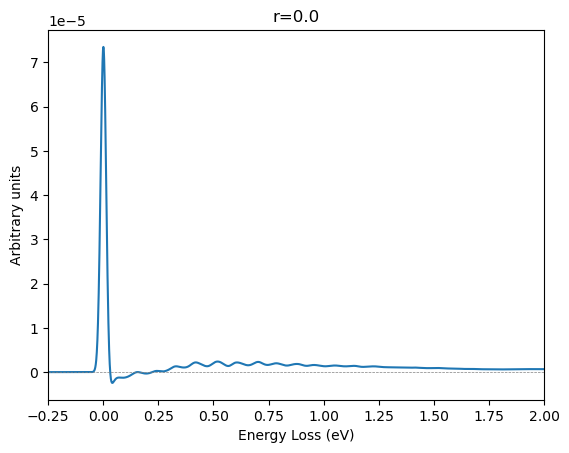

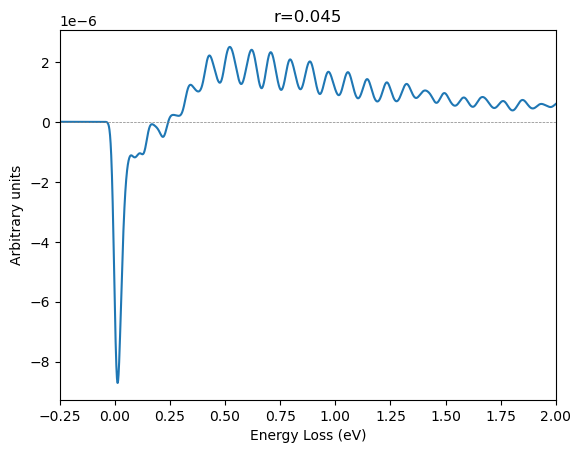

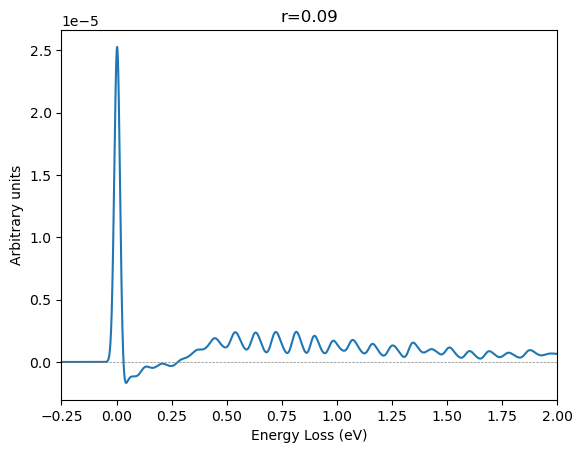

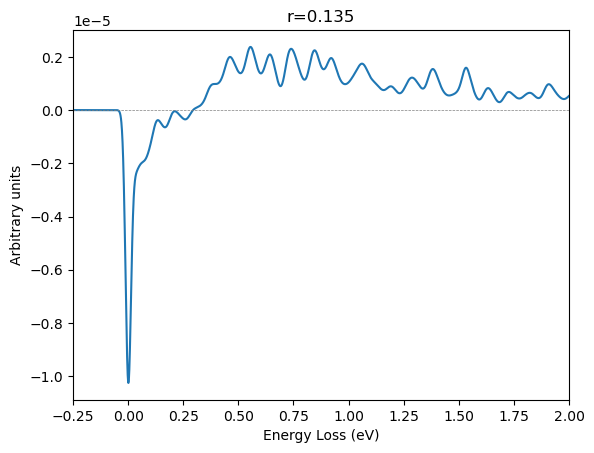

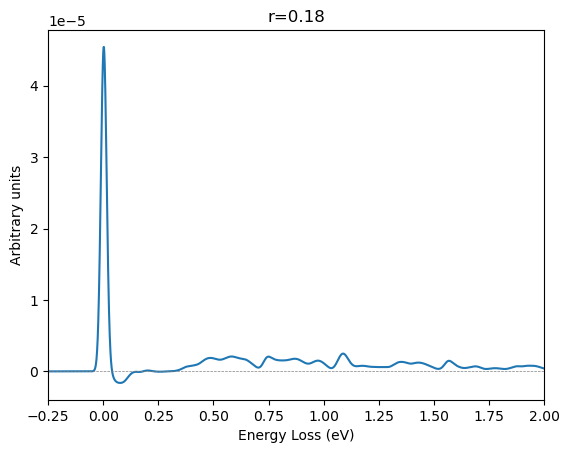

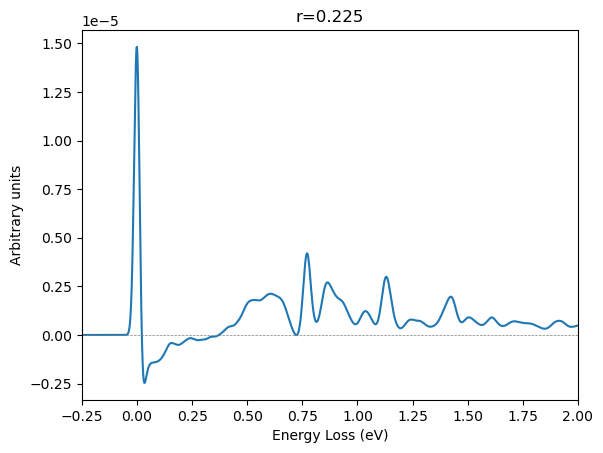

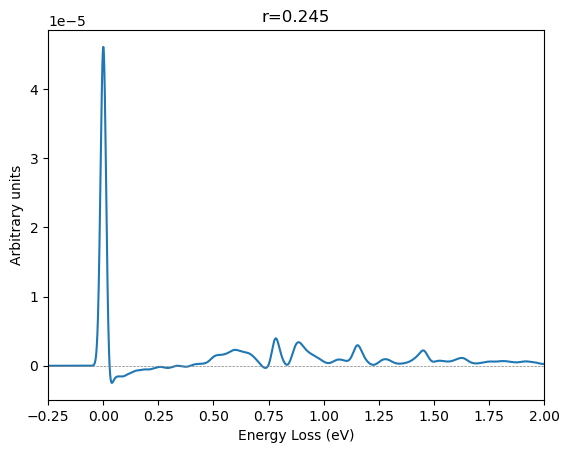

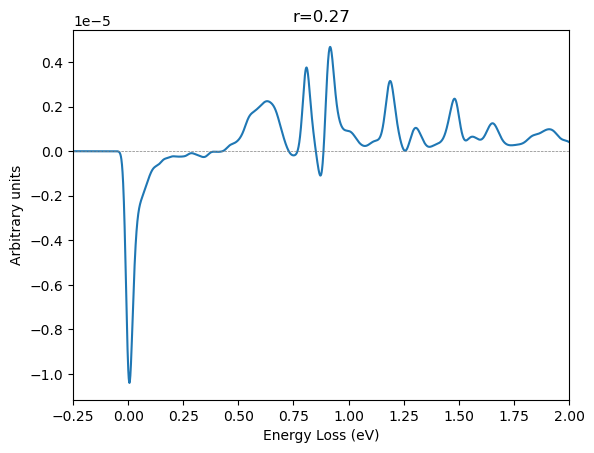

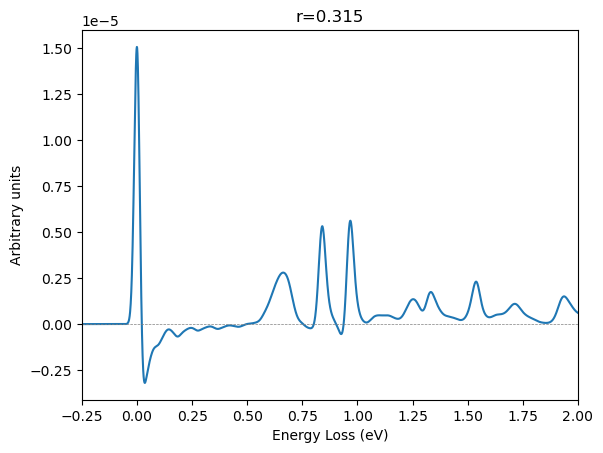

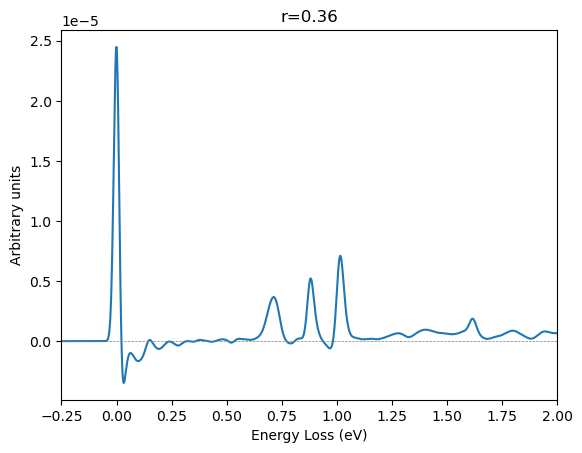

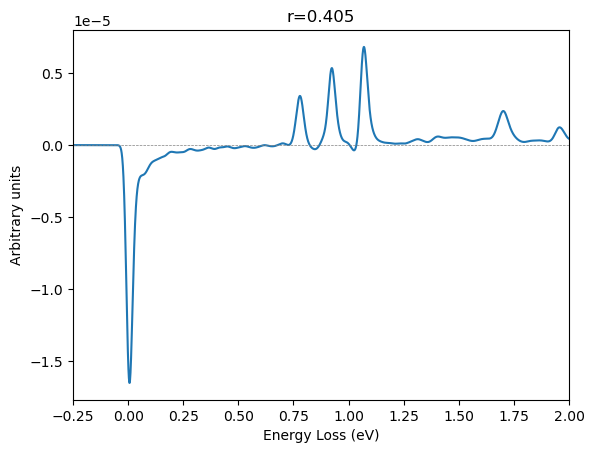

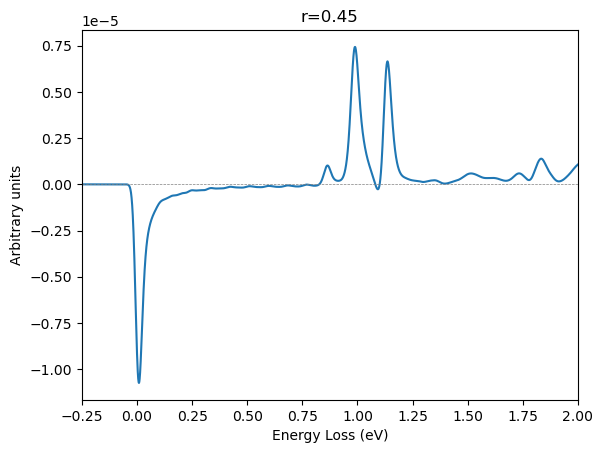

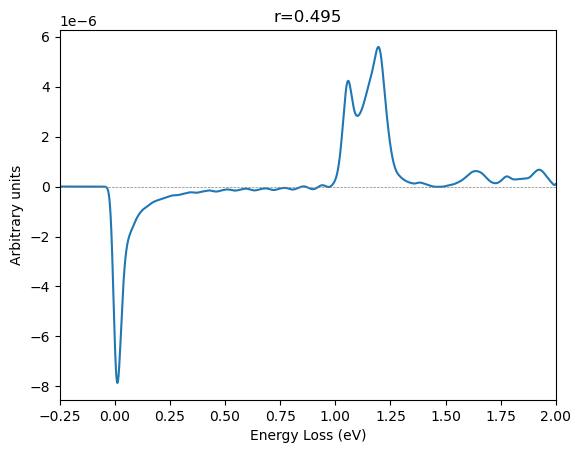

In [ ]:
np.linspace(0,0.495,12)[:]
for i, Gamma_c in zip(list(np.linspace(0,0.495,12)[:6]) + [0.245] + list(np.linspace(0,0.495,12)[6:]), Gamma_c_list):
    plt.figure()
    plt.title(f"r={i:.3}")
    plt.plot((freqs_ext*h_bar/q_e)[int(0*M):], Gamma_c[int(0*M):])
    plt.hlines(y=0,xmin=-0.25,xmax=2, ls='--', lw=0.5, color='grey')
    plt.xlabel('Energy Loss (eV)')
    plt.ylabel('Arbitrary units')
    plt.xlim((-0.25,2))